In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvals
#from tqdm import tqdm

In [5]:
# ----- initial parameters -----

N = 50
W1 = 2.0
W2 = 2.0
W3 = 1.0
tau = 5.0
I = 2.0
n_t = 0.0   # noise at time t


In [9]:
# ----- build the weight matrix -----

def weight_matrix(M, W1, W2, W3):
    """
    Build the weight matrix for analyzing M-WTA.
    We consider M active neurons plus 1 neighboring neuron (total size M+1).
    """
    size = M + 1
    W = np.zeros((size, size))
    
    # global inhibition among these neurons
    W -= W2
    
    # self excitation
    for i in range(size):
        W[i, i] += W1
    
    # nearest-neighbor excitation (linear chain)
    for i in range(size - 1):
        W[i, i+1] += W3
        W[i+1, i] += W3
    
    return W

In [18]:
M = 3
W = weight_matrix(M, W1, W2, W3)
W

array([[ 0., -1., -2., -2.],
       [-1.,  0., -1., -2.],
       [-2., -1.,  0., -1.],
       [-2., -2., -1.,  0.]])

In [24]:
#stability condition
eigenvalues = np.linalg.eigvals(W)
stable = eigenvalues[0] < 1

[-4.54138127  0.38196601  2.61803399  1.54138127]


np.True_

In [19]:
def check_MWTA_consistency(M, W1, W2, W3, I, tol=1e-12):
    """
    Consistency for M-WTA at steady state (dx/dt = 0) with ReLU:
      - consistency requires all x1,x2,...,xm > 0

    Uses the active-neuron steady-state equation:
      x_A = W_AA x_A + I_ext * 1
      => (I - W_AA) x_A = I_ext * 1
    """
    W = weight_matrix(M, W1, W2, W3)   
    W_AA = W[:M, :M]                        # active block of M by M matrix

    A = np.eye(M) - W_AA
    b = I * np.ones(M)
 
    try:
        xA = np.linalg.solve(A, b)          # steady-state
    except np.linalg.LinAlgError:
        return False, None

    return np.all(xA > tol), xA

ok, xA = check_MWTA_consistency(M, W1, W2, W3, I)
print("consistent:", ok)
print("x1,x2,x3:", xA)


consistent: False
x1,x2,x3: [0. 2. 0.]


In [22]:
# Parameter grid
W1_vals = np.arange(0, 5.01, 0.01)
W3_vals = np.arange(0, 5.01, 0.01)

# Active range
#M_values = range(1, 11)

array([[ 0., -1., -2., -2.],
       [-1.,  0., -1., -2.],
       [-2., -1.,  0., -1.],
       [-2., -2., -1.,  0.]])

## Grid of W1 and W3

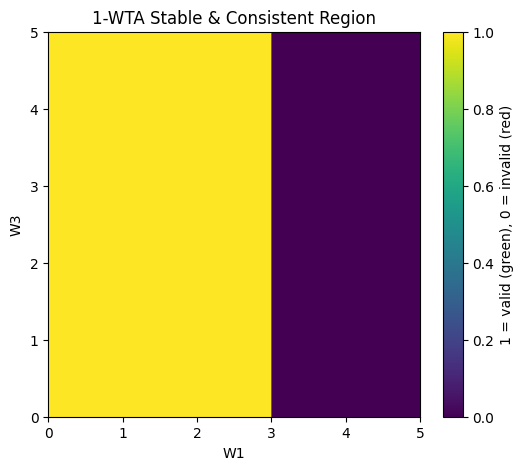

In [34]:

# grid
W1_vals = np.arange(0, 5.01, 0.01)
W3_vals = np.arange(0, 5.01, 0.01)

M = 1
W2 = 2.0
I_ext = 2.0

phase = np.zeros((len(W1_vals), len(W3_vals)))

for i, W1 in enumerate(W1_vals):
    for j, W3 in enumerate(W3_vals):
        
        W = weight_matrix(M, W1, W2, W3)
        
        # --- stability --- (solve M by M matrix and see if all the the eigenvalues are less than 1 else return false)
        eigenvalues = np.linalg.eigvals(W[:M, :M])
        stable = np.all(np.real(eigenvalues) < 1)
        
        # --- consistency --- #steady state checking if all the activity x's are positives else return false if true go to the next step
        A = np.eye(M) - W[:M, :M]
        b = I_ext * np.ones(M)
        try:
            xA = np.linalg.solve(A, b)
            consistent = np.all(xA > 0)
        except:
            consistent = False
        
        if stable and consistent:
            phase[i, j] = 1

        #neighbouring activities in steady state RHS should be negative for left neighbour and right neighbour
        #x_left = -w2 * total activity + W3 * x1 + I
        #x_right = -w2 * total activity + W3 * xm + I
        #(M+1) should be unstable

# plot
plt.figure(figsize=(6,5))
plt.imshow(
    phase.T,
    extent=[0,5,0,5],
    origin='lower',
    aspect='auto'
)
plt.xlabel("W1")
plt.ylabel("W3")
plt.title(f"{M}-WTA Stable & Consistent Region")
plt.colorbar(label="1 = valid (green), 0 = invalid (red)")
plt.show()

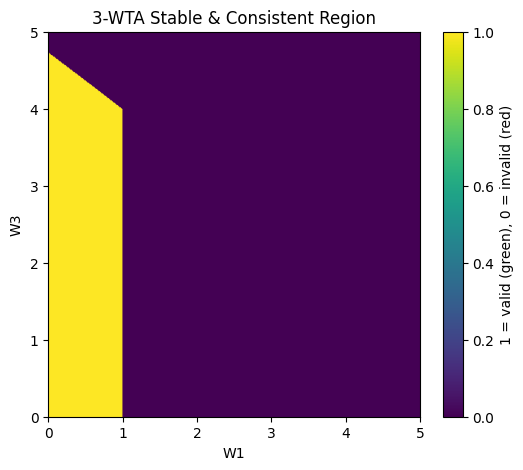

In [26]:

# grid
W1_vals = np.arange(0, 5.01, 0.01)
W3_vals = np.arange(0, 5.01, 0.01)

M = 3
W2 = 2.0
I_ext = 2.0

phase = np.zeros((len(W1_vals), len(W3_vals)))

for i, W1 in enumerate(W1_vals):
    for j, W3 in enumerate(W3_vals):
        
        W = weight_matrix(M, W1, W2, W3)
        
        # --- stability ---
        eigenvalues = np.linalg.eigvals(W[:M, :M])
        stable = np.all(np.real(eigenvalues) < 1)
        
        # --- consistency ---
        A = np.eye(M) - W[:M, :M]
        b = I_ext * np.ones(M)
        try:
            xA = np.linalg.solve(A, b)
            consistent = np.all(xA > 0)
        except:
            consistent = False
        
        if stable and consistent:
            phase[i, j] = 1

# plot
plt.figure(figsize=(6,5))
plt.imshow(
    phase.T,
    extent=[0,5,0,5],
    origin='lower',
    aspect='auto'
)
plt.xlabel("W1")
plt.ylabel("W3")
plt.title("3-WTA Stable & Consistent Region")
plt.colorbar(label="1 = valid (green), 0 = invalid (red)")
plt.show()


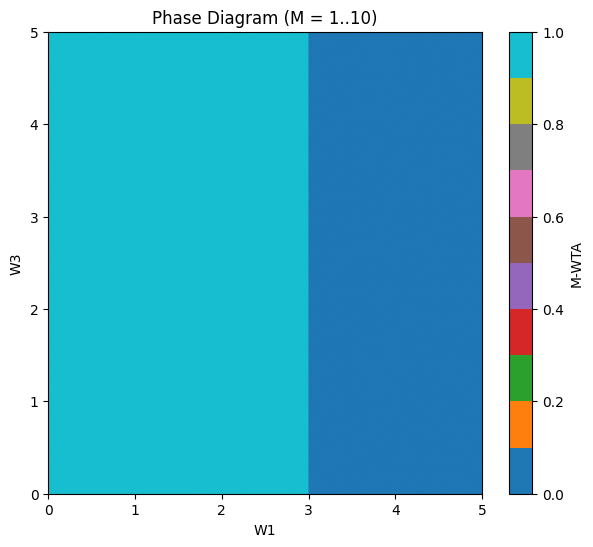

In [28]:
# grid
W1_vals = np.arange(0, 5.01, 0.01)
W3_vals = np.arange(0, 5.01, 0.01)

W2 = 2.0
I_ext = 2.0

phase = np.zeros((len(W1_vals), len(W3_vals)))  # stores M (1..10)

for i, W1 in enumerate(W1_vals):
    for j, W3 in enumerate(W3_vals):
        
        for M in range(1, 11):
            
            W = weight_matrix(M, W1, W2, W3)
            
            # stability
            eigenvalues = np.linalg.eigvals(W[:M, :M])
            stable = np.all(np.real(eigenvalues) < 1)
            
            # consistency
            A = np.eye(M) - W[:M, :M]
            b = I_ext * np.ones(M)
            try:
                xA = np.linalg.solve(A, b)
                consistent = np.all(xA > 0)
            except:
                consistent = False
            
            if stable and consistent:
                phase[i, j] = M  # store this M
                break            # stop at first valid M

# plot
plt.figure(figsize=(7,6))
plt.imshow(
    phase.T,
    extent=[0,5,0,5],
    origin='lower',
    aspect='auto',
    cmap='tab10'
)
plt.xlabel("W1")
plt.ylabel("W3")
plt.title("Phase Diagram (M = 1..10)")
plt.colorbar(label="M-WTA")
plt.show()
